Text(0.5, 1.0, 'Energy and Buckling Height vs Strain for Relaxed BiSb')

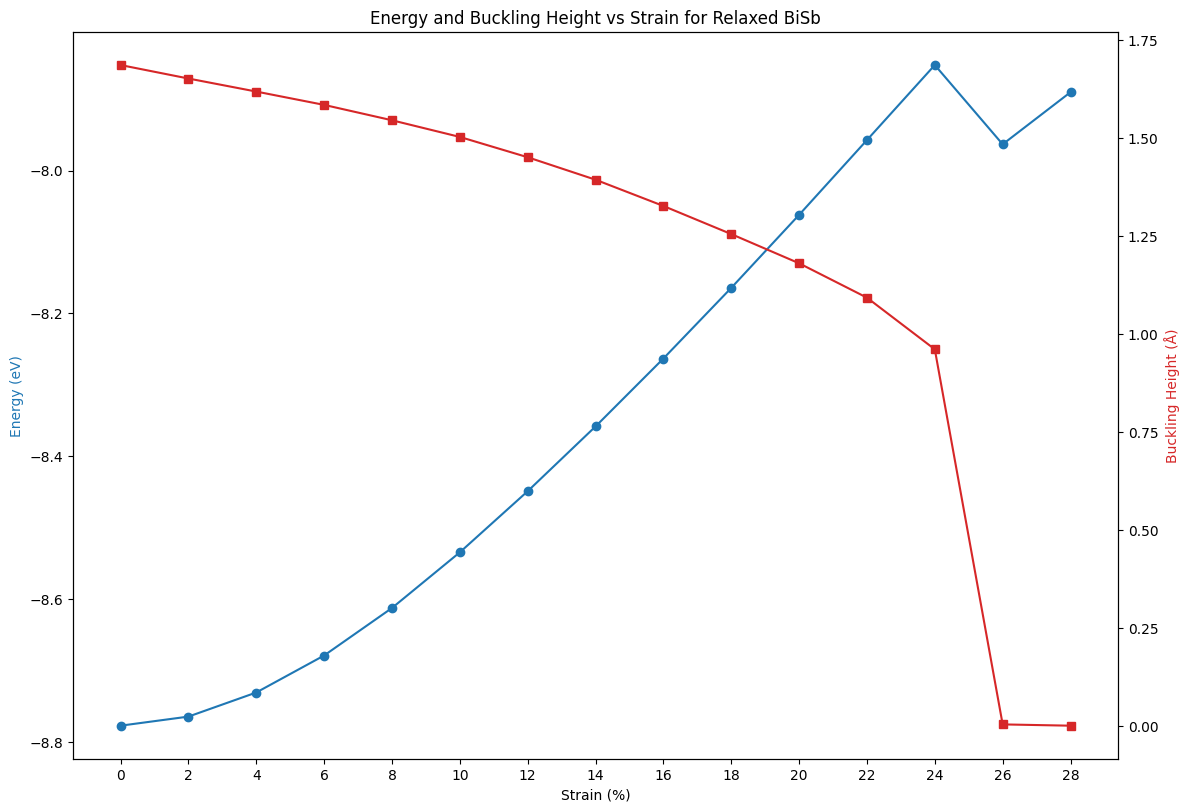

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Strain and buckling height parameters
strain = np.array([0,2,4,6,8,10,12,14,16,18,20,22,24,26,28])
buckling_height = np.array([1.68685,1.65242,1.61913,1.58509,1.54584,1.50327,1.45144,1.39406,1.32706,1.25528,1.18070,1.09291,0.96102,0.00344,0.00015])
energies = np.array([-.87769129E+01,-.87642022E+01,-.87304770E+01,-.86786981E+01,-.86122161E+01 ,-.85342897E+01,-.84487670E+01,
                     -.83581182E+01,-.82630593E+01 ,-.81642023E+01,-.80619731E+01,-.79573097E+01,-.78522868E+01,-.79632246E+01,-.78902774E+01])
#Plotting energy and buckling height vs strain
fig, ax1 = plt.subplots(figsize=(12,8))
color = 'tab:blue'
ax1.set_xlabel('Strain (%)')
ax1.set_ylabel('Energy (eV)', color=color)
ax1.plot(strain, energies, marker='o', color=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Buckling Height (Å)', color=color)
ax2.plot(strain, buckling_height, marker='s', color=color)

plt.xticks(strain)
fig.tight_layout()
plt.title('Energy and Buckling Height vs Strain for Relaxed BiSb')

Number of bands below Fermi level in DFT data: 20


(-7.0, 7.0)

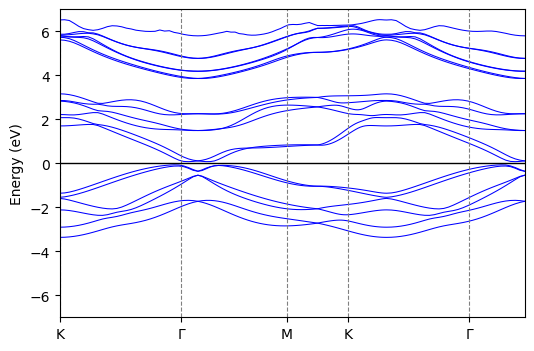

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data_dft = np.loadtxt("e11-REFORMATTED_BAND.dat")
data_wan = np.loadtxt("e11-wannier90_band.dat")

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]

fermi = np.array([-1.3748,-1.6897,-1.9709,-2.1540,-2.2441,
                  -2.3166,-2.3540,-2.3914,-2.4484,-2.5217,
                  -2.6157,-2.7160,-2.8273,-2.9461,-3.0196])

k_wan = np.unique(data_wan[:, 0])
bands_wan = np.reshape(data_wan[:, 1], (-1, len(k_wan)))

high_symmetry_points = [0,0.780,1.456,1.846,2.626]
high_sym_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

k_wan = k_wan * (max(k_dft) / max(k_wan))

#number of bands below fermi level in DFT data
num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(6,4))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")
  
#for i in range(bands_wan.shape[0]):
    #plt.plot(k_wan, bands_wan[i, :], color='red', linestyle='--', linewidth=0.75, label='Wannier90' if i == 0 else "")

for x in high_symmetry_points:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.8)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.xticks(high_symmetry_points, high_sym_labels)
plt.ylabel('Energy (eV)')
#plt.title('Band Structure for $\epsilon$ = 24', fontsize=16)
plt.xlim(min(k_dft), max(k_dft))
plt.ylim(-7, 7)


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-12-17 00:36:59,454                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

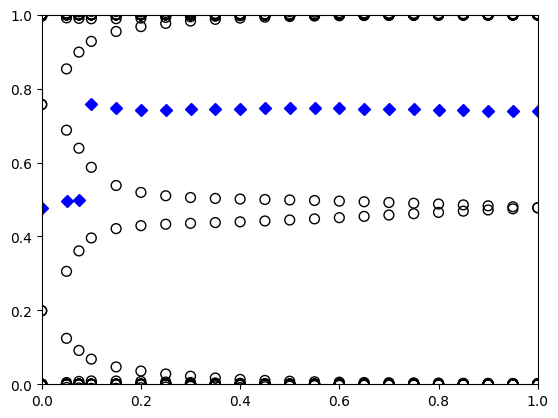

In [50]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='e11-wannier90_hr.dat', wsvec_file='e11-wannier90_wsvec.dat',occ=20)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_10568\1148748805.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r"e28-PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


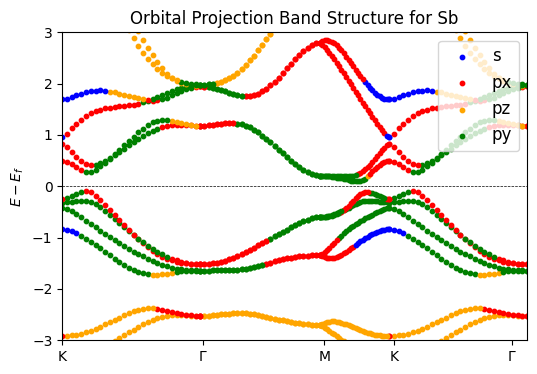

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"e28-PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


k = np.array(data[0])
e = np.array(data[1])
s = np.array([[value, 'blue'] for value in data[2]], dtype=object)
s = np.transpose(s)
px = np.array([[value, 'red'] for value in data[3]], dtype=object)
px = np.transpose(px)
py = np.array([[value, 'green'] for value in data[4]], dtype=object)
py = np.transpose(py)
pz = np.array([[value, 'orange'] for value in data[5]], dtype=object)
pz = np.transpose(pz)

plt.figure(figsize=(6,4))

# Track which labels we've already added
labels_added = set()

for i in range(len(s[0])):
    # Create pairs of (value, color) for this index
    sorting = [
        (k[i], e[i], s[0][i], s[1][i], 's'),      # Added orbital name
        (k[i], e[i], px[0][i], px[1][i], 'px'),    
        (k[i], e[i], py[0][i], py[1][i], 'py'),    
        (k[i], e[i], pz[0][i], pz[1][i], 'pz')     
    ]
    
    data = sorted(sorting, key=lambda x: x[2], reverse=True)
    
    # Only add label if we haven't seen this orbital type before
    orbital_name = data[0][4]
    if orbital_name not in labels_added:
        plt.scatter(data[0][0], data[0][1], color=data[0][3], s=10, label=orbital_name)
        labels_added.add(orbital_name)
    else:
        plt.scatter(data[0][0], data[0][1], color=data[0][3], s=10)

plt.ylim(-3,3)
plt.xlim(min(k), max(k)) 
plt.ylabel(r'$E-E_f$')
plt.legend(frameon=True, loc='upper right', fontsize=12)
plt.axhline(0, ls='--', lw=0.5, color='black')
#plt.axvline(0.954, ls='--', lw=0.5, color='black')
#plt.axvline(1.781, ls='--', lw=0.5, color='black')       
#plt.axvline(2.258, ls='--', lw=0.5, color='black')  
plt.xticks(ticks=[0,0.780,1.456,1.846,2.500], labels=['K', '$\Gamma$', 'M', 'K', '$\Gamma$'])
plt.title('Orbital Projection Band Structure for Sb')
plt.show()





C:\Users\furka\AppData\Local\Temp\ipykernel_17524\246061133.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r"e28-PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


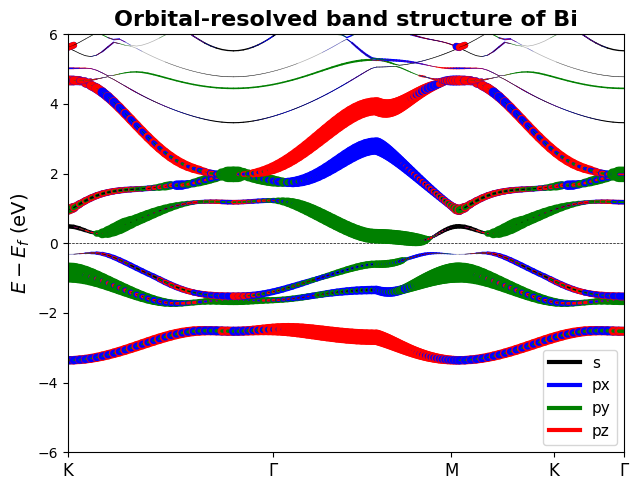

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"e28-PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data[0])
e = np.array(data[1])
s = np.array(data[2])
px = np.array(data[3])
py = np.array(data[4])
pz = np.array(data[5])

# Identify individual bands
bands_k = []
bands_e = []
bands_s = []
bands_px = []
bands_py = []
bands_pz = []

current_band_k = [k[0]]
current_band_e = [e[0]]
current_band_s = [s[0]]
current_band_px = [px[0]]
current_band_py = [py[0]]
current_band_pz = [pz[0]]

for i in range(1, len(k)):
    if k[i] <= k[i-1]:
        bands_k.append(np.array(current_band_k))
        bands_e.append(np.array(current_band_e))
        bands_s.append(np.array(current_band_s))
        bands_px.append(np.array(current_band_px))
        bands_py.append(np.array(current_band_py))
        bands_pz.append(np.array(current_band_pz))
        
        current_band_k = [k[i]]
        current_band_e = [e[i]]
        current_band_s = [s[i]]
        current_band_px = [px[i]]
        current_band_py = [py[i]]
        current_band_pz = [pz[i]]
    else:
        current_band_k.append(k[i])
        current_band_e.append(e[i])
        current_band_s.append(s[i])
        current_band_px.append(px[i])
        current_band_py.append(py[i])
        current_band_pz.append(pz[i])

bands_k.append(np.array(current_band_k))
bands_e.append(np.array(current_band_e))
bands_s.append(np.array(current_band_s))
bands_px.append(np.array(current_band_px))
bands_py.append(np.array(current_band_py))
bands_pz.append(np.array(current_band_pz))

# Create single plot
fig, ax = plt.subplots(figsize=(6.5, 5))

orbitals_list = [bands_s, bands_px, bands_py, bands_pz]
colors = ['black', 'blue', 'green', 'red']
names = ['s', 'px', 'py', 'pz']

width_scale = 50

# Plot each band
for i in range(len(bands_k)):
    k_band = bands_k[i]
    e_band = bands_e[i]
    
    # For each segment, collect all orbital contributions and sort by size
    for j in range(len(k_band) - 1):
        # Get contributions from all orbitals for this segment
        contributions = [
            ((bands_s[i][j] + bands_s[i][j+1]) / 2, 'black', 's'),
            ((bands_px[i][j] + bands_px[i][j+1]) / 2, 'blue', 'px'),
            ((bands_py[i][j] + bands_py[i][j+1]) / 2, 'green', 'py'),
            ((bands_pz[i][j] + bands_pz[i][j+1]) / 2, 'red', 'pz')
        ]
        
        # Sort by contribution (largest first, so it's drawn first/on bottom)
        contributions.sort(reverse=True, key=lambda x: x[0])
        
        # Plot each orbital contribution in order (largest to smallest)
        for contrib, color, label in contributions:
            lw = contrib * width_scale
            if lw > 0.1:
                ax.plot(k_band[j:j+2], e_band[j:j+2], 
                       color=color, linewidth=lw, alpha=1, 
                       solid_capstyle='round', zorder=1)

# Add thin background lines to show all bands
for i in range(len(bands_k)):
    ax.plot(bands_k[i], bands_e[i], color='black', linewidth=0.5, alpha=0.3, zorder=0)

ax.set_title('Orbital-resolved band structure of Bi', fontsize=16, fontweight='bold')
ax.set_ylim(-6, 6)
ax.set_xlim(min(k), max(k))
ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)

# Add grid lines
ax.axhline(0, ls='--', lw=0.5, color='black', zorder=0)

# X-axis labels
ax.set_xticks([0, 0.954, 1.781, 2.258, max(k)])
ax.set_xticklabels(['K', '$\Gamma$', 'M', 'K', '$\Gamma$'], fontsize=12)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=3, label='s'),
    Line2D([0], [0], color='blue', lw=3, label='px'),
    Line2D([0], [0], color='green', lw=3, label='py'),
    Line2D([0], [0], color='red', lw=3, label='pz')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_17524\3337077679.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r"e28-PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


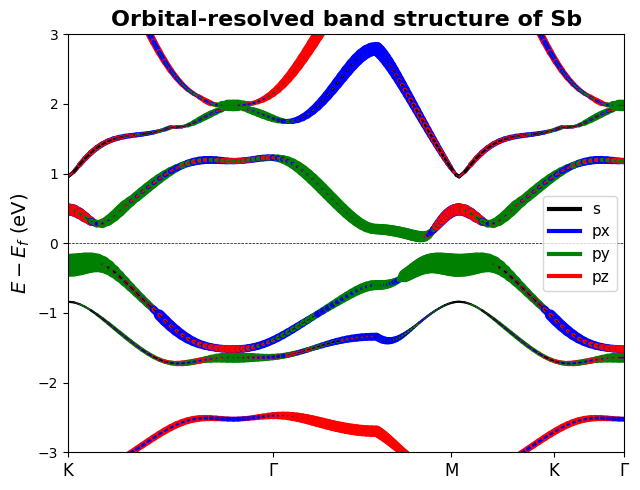

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"e28-PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data[0])
e = np.array(data[1])
s = np.array(data[2])
px = np.array(data[3])
py = np.array(data[4])
pz = np.array(data[5])

# Identify individual bands
bands_k = []
bands_e = []
bands_s = []
bands_px = []
bands_py = []
bands_pz = []

current_band_k = [k[0]]
current_band_e = [e[0]]
current_band_s = [s[0]]
current_band_px = [px[0]]
current_band_py = [py[0]]
current_band_pz = [pz[0]]

for i in range(1, len(k)):
    if k[i] <= k[i-1]:
        bands_k.append(np.array(current_band_k))
        bands_e.append(np.array(current_band_e))
        bands_s.append(np.array(current_band_s))
        bands_px.append(np.array(current_band_px))
        bands_py.append(np.array(current_band_py))
        bands_pz.append(np.array(current_band_pz))
        
        current_band_k = [k[i]]
        current_band_e = [e[i]]
        current_band_s = [s[i]]
        current_band_px = [px[i]]
        current_band_py = [py[i]]
        current_band_pz = [pz[i]]
    else:
        current_band_k.append(k[i])
        current_band_e.append(e[i])
        current_band_s.append(s[i])
        current_band_px.append(px[i])
        current_band_py.append(py[i])
        current_band_pz.append(pz[i])

bands_k.append(np.array(current_band_k))
bands_e.append(np.array(current_band_e))
bands_s.append(np.array(current_band_s))
bands_px.append(np.array(current_band_px))
bands_py.append(np.array(current_band_py))
bands_pz.append(np.array(current_band_pz))

# Create single plot
fig, ax = plt.subplots(figsize=(6.5, 5))

orbitals_list = [bands_s, bands_px, bands_py, bands_pz]
colors = ['black', 'blue', 'green', 'red']
names = ['s', 'px', 'py', 'pz']

width_scale = 50

# Plot each band
for i in range(len(bands_k)):
    k_band = bands_k[i]
    e_band = bands_e[i]
    
    # For each segment, collect all orbital contributions and sort by size
    for j in range(len(k_band) - 1):
        # Get contributions from all orbitals for this segment
        contributions = [
            ((bands_s[i][j] + bands_s[i][j+1]) / 2, 'black', 's'),
            ((bands_px[i][j] + bands_px[i][j+1]) / 2, 'blue', 'px'),
            ((bands_py[i][j] + bands_py[i][j+1]) / 2, 'green', 'py'),
            ((bands_pz[i][j] + bands_pz[i][j+1]) / 2, 'red', 'pz')
        ]
        
        # Sort by contribution (largest first, so it's drawn first/on bottom)
        contributions.sort(reverse=True, key=lambda x: x[0])
        
        # Plot each orbital contribution in order (largest to smallest)
        for contrib, color, label in contributions:
            lw = contrib * width_scale
            if lw > 0.1:
                ax.plot(k_band[j:j+2], e_band[j:j+2], 
                       color=color, linewidth=lw, alpha=1, 
                       solid_capstyle='round', zorder=1)

# Add thin background lines to show all bands
for i in range(len(bands_k)):
    ax.plot(bands_k[i], bands_e[i], color='black', linewidth=0.5, alpha=0.3, zorder=0)

ax.set_title('Orbital-resolved band structure of Sb', fontsize=16, fontweight='bold')
ax.set_ylim(-3, 3)
ax.set_xlim(min(k), max(k))
ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)

# Add grid lines
ax.axhline(0, ls='--', lw=0.5, color='black', zorder=0)

# X-axis labels
ax.set_xticks([0, 0.954, 1.781, 2.258, max(k)])
ax.set_xticklabels(['K', '$\Gamma$', 'M', 'K', '$\Gamma$'], fontsize=12)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=3, label='s'),
    Line2D([0], [0], color='blue', lw=3, label='px'),
    Line2D([0], [0], color='green', lw=3, label='py'),
    Line2D([0], [0], color='red', lw=3, label='pz')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_20196\1254356233.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r"e0-PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


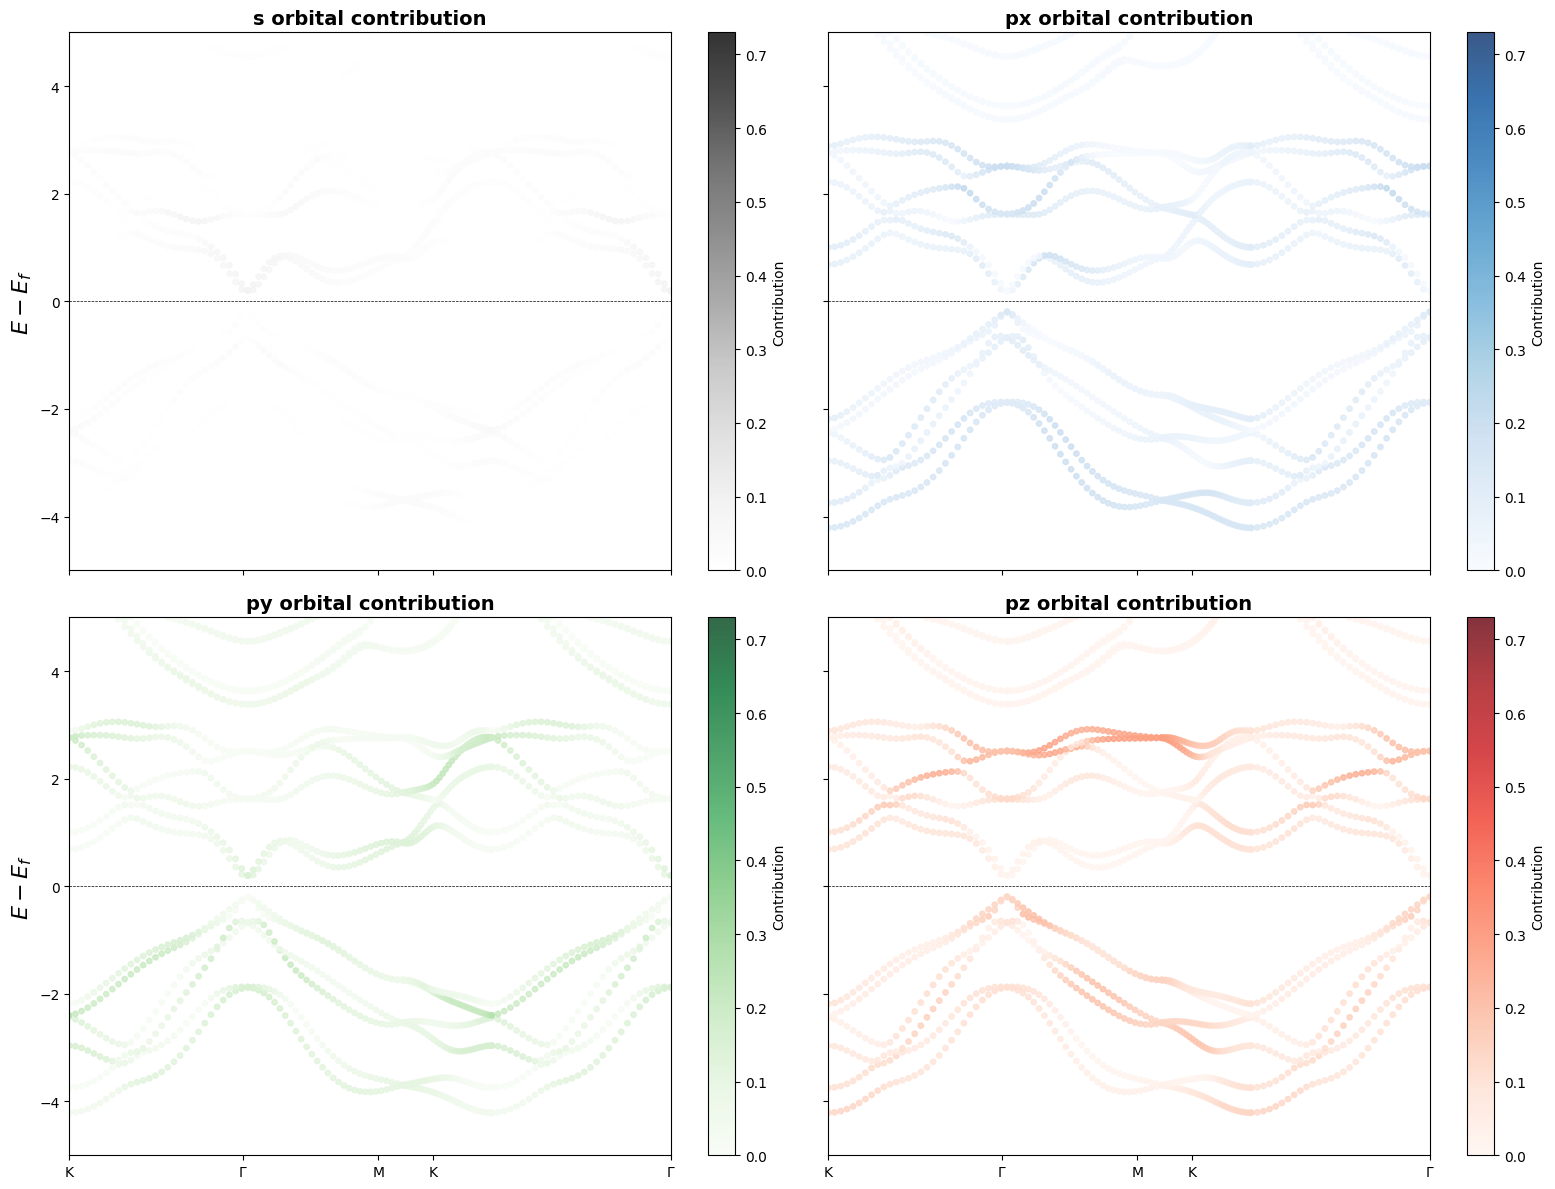

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"e0-PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data[0])
e = np.array(data[1])
s = np.array(data[2])
px = np.array(data[3])
py = np.array(data[4])
pz = np.array(data[5])

# Find global min and max across all orbitals for consistent colorbar scale
all_contributions = np.concatenate([s, px, py, pz])
vmin = np.min(all_contributions)
vmax = np.max(all_contributions)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

orbitals = [s, px, py, pz]
# Different sequential colormaps for each orbital
colormaps = ['Greys', 'Blues', 'Greens', 'Reds']
names = ['s', 'px', 'py', 'pz']

for idx, (orbital, cmap, name) in enumerate(zip(orbitals, colormaps, names)):
    ax = axes[idx]
    
    # Use the same vmin and vmax for all subplots
    scatter = ax.scatter(k, e, c=orbital, s=15, cmap=cmap, alpha=0.8, vmin=vmin, vmax=vmax)
    
    ax.set_title(f'{name} orbital contribution', fontsize=14, fontweight='bold')
    ax.set_ylim(-5, 5)
    ax.set_xlim(min(k), max(k))
    
    # Add colorbar for each subplot with consistent scale
    cbar = plt.colorbar(scatter, ax=ax, label='Contribution')
    cbar.ax.tick_params(labelsize=10)
    
    # Add the same grid lines to each subplot
    ax.axhline(0, ls='--', lw=0.5, color='black')

    
    # Add x-axis labels only to bottom subplots
    if idx >= 2:
        ax.set_xticks([0, 0.954, 1.7, 2, max(k)])
        ax.set_xticklabels(['K', '$\Gamma$', 'M', 'K', '$\Gamma$'])
    
    # Add y-axis label to left subplots
    if idx % 2 == 0:
        ax.set_ylabel(r'$E-E_f$', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14]
labels = ['2', '4', '6', '8', '10', '12', '14']

# Define elements and their corresponding columns
element_names = ['Bi', 'Sb']  # Adjust as needed
element_columns = [2, 3]  # Adjust as needed
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# High symmetry points
high_sym_points = [0, 0.425, 1.276, 2.127]
high_sym_labels = ['X', 'Γ', 'M', 'Γ', 'Y']

# Create figure with subplots (2 rows, 4 columns to accommodate 7 plots)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Plot each dataset
for idx, (elemented_data, label) in enumerate(zip(datasets, labels)):
    ax = axes[idx]
    
    # Find which element is dominant at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)
    
    # Find where the dominant element changes
    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    
    # Add start and end indices
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))
    
    # Keep track of which elements have been labeled
    labeled_elements = set()
    
    # Plot each segment
    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]
        
        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]
        
        # Only add label for the first occurrence of each element
        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1], 
                    color=color, label=elem_label, linewidth=0.5)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1], 
                    color=color, linewidth=0.5)
    
    # Formatting for each subplot
    ax.set_xticks(high_sym_points + [max(elemented_data[:,0])])
    ax.set_xticklabels(high_sym_labels)
    ax.set_xlim(min(elemented_data[:,0]), max(elemented_data[:,0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain')
    ax.set_ylabel('Energy')
    ax.legend(loc='best', fontsize=8)

# Hide the last (8th) unused subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Uniaxial Strain along x direction", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

Global DOS range: [2.05377, 7.8029016]


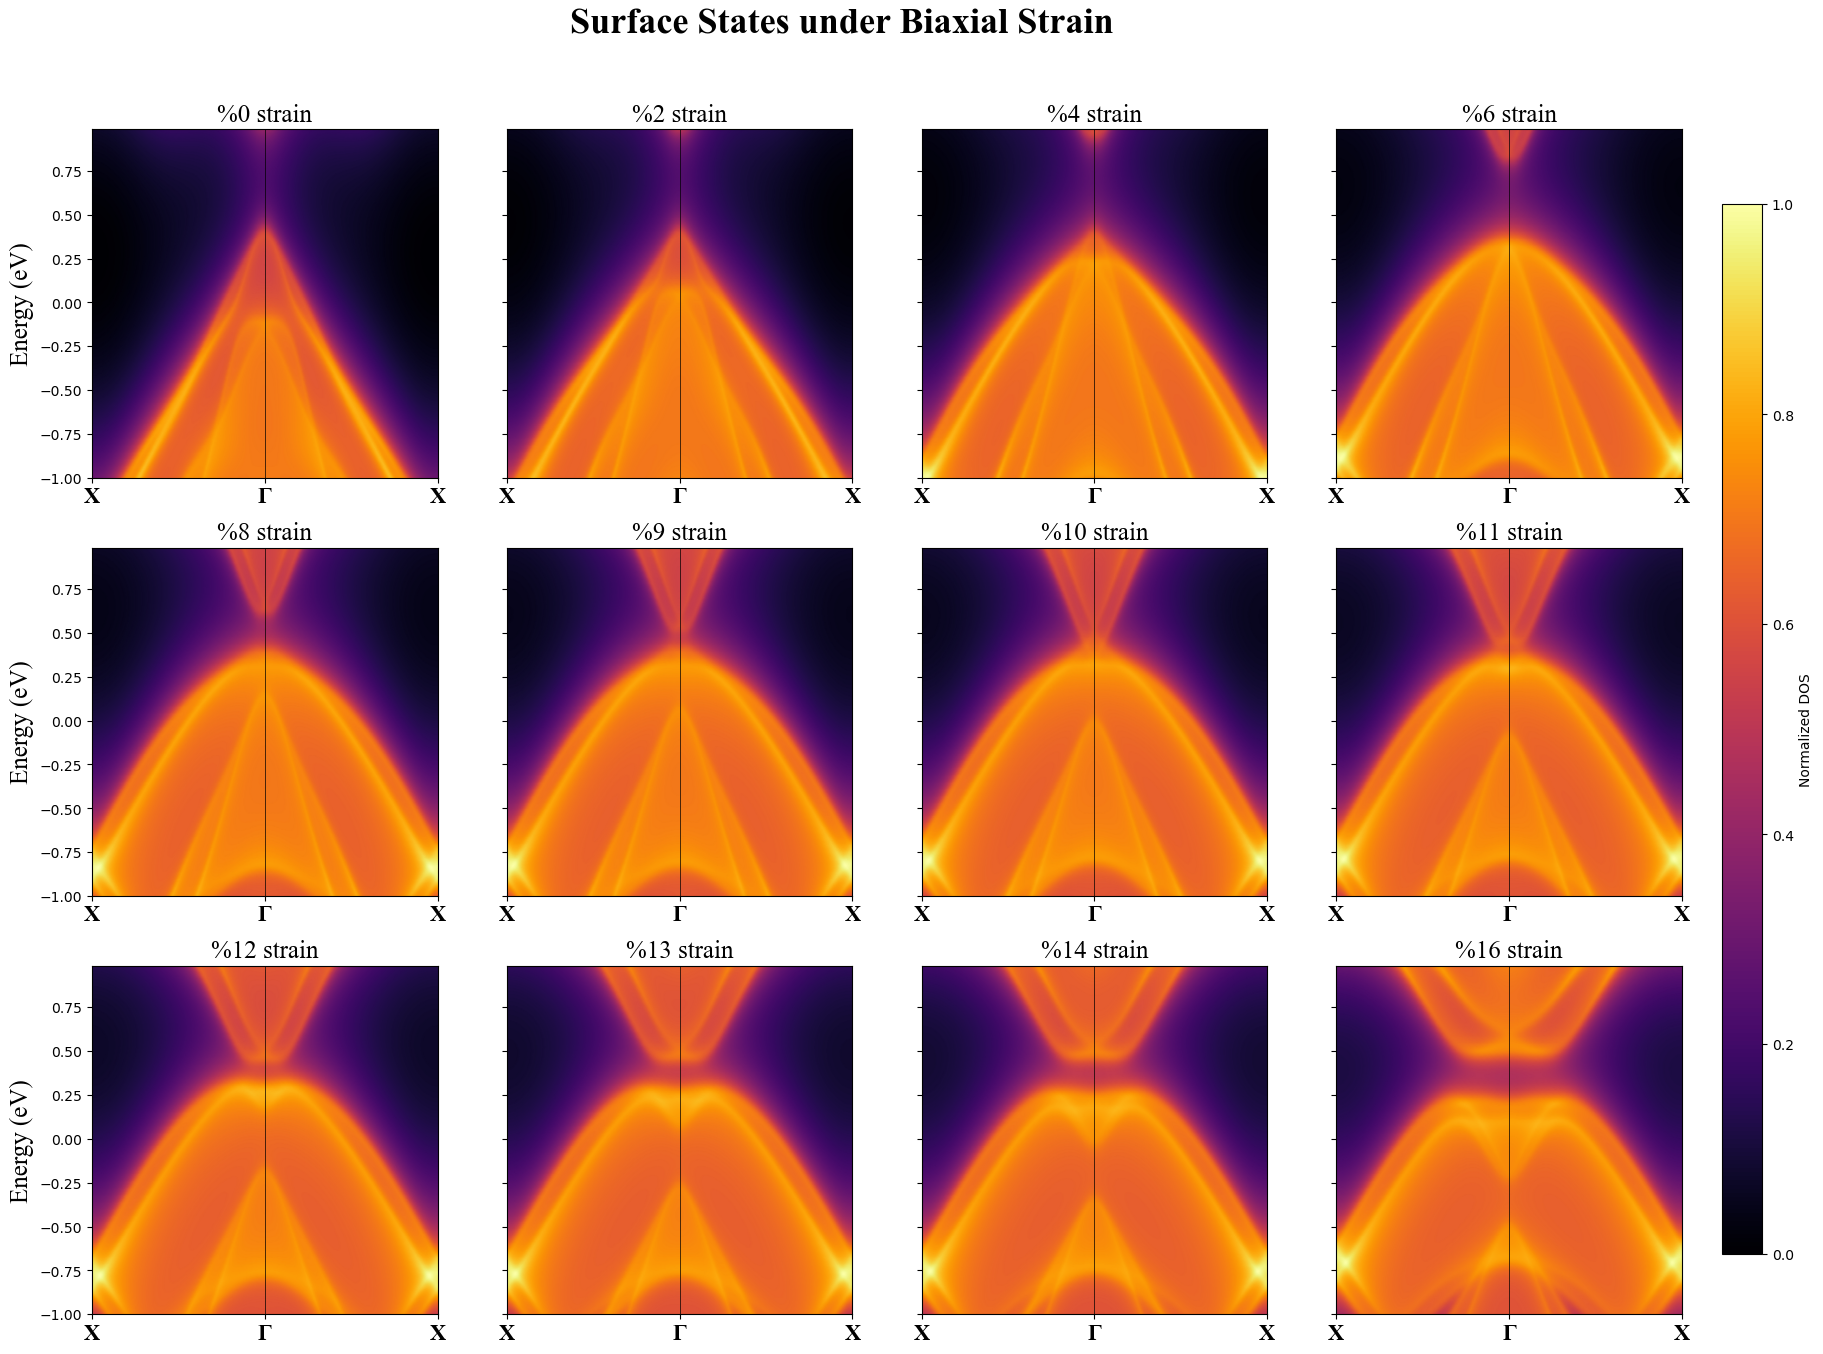

Plot displayed!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_0 = np.loadtxt("0-dos.dat_bulk")
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_9 = np.loadtxt("9-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_11 = np.loadtxt("11-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_13 = np.loadtxt("13-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")

# Collect all datasets
datasets = [data_0, data_2, data_4, data_6, data_8, data_9, data_10, data_11, data_12, data_13, data_14, data_16]
labels = ['0', '2', '4', '6', '8', '9', '10', '11', '12', '13', '14', '16']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap="inferno", shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'],fontname="Times New Roman", fontweight="bold",fontsize=16)
    
    # Set y-axis label
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"%{title_suffix} strain",fontname="Times New Roman", fontsize=18)

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(3, 4, figsize=(20, 15),sharey=True)
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])
    if i == 0 or i == 4 or i == 8:
        axes[i].set_ylabel('Energy (eV)', fontname="Times New Roman", fontsize=18)
# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title

# Add overall title at the top
fig.suptitle("Surface States under Biaxial Strain", fontname="Times New Roman", fontweight="bold",fontsize=26, y=0.98)

# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.savefig("surface_states_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot displayed!")

[0.0, 0.983, 1.834, 2.325, 3.308]
[0.0, 0.964, 1.798, 2.28, 3.243]
[0.0, 0.945, 1.763, 2.236, 3.181]
[0.0, 0.927, 1.73, 2.194, 3.121]
[0.0, 0.91, 1.698, 2.153, 3.063]
[0.0, 0.902, 1.683, 2.133, 3.035]
[0.0, 0.893, 1.667, 2.114, 3.007]
[0.0, 0.885, 1.652, 2.095, 2.98]
[0.0, 0.878, 1.637, 2.076, 2.954]
[0.0, 0.87, 1.623, 2.058, 2.928]
[0.0, 0.862, 1.609, 2.04, 2.902]
[0.0, 0.847, 1.581, 2.005, 2.852]


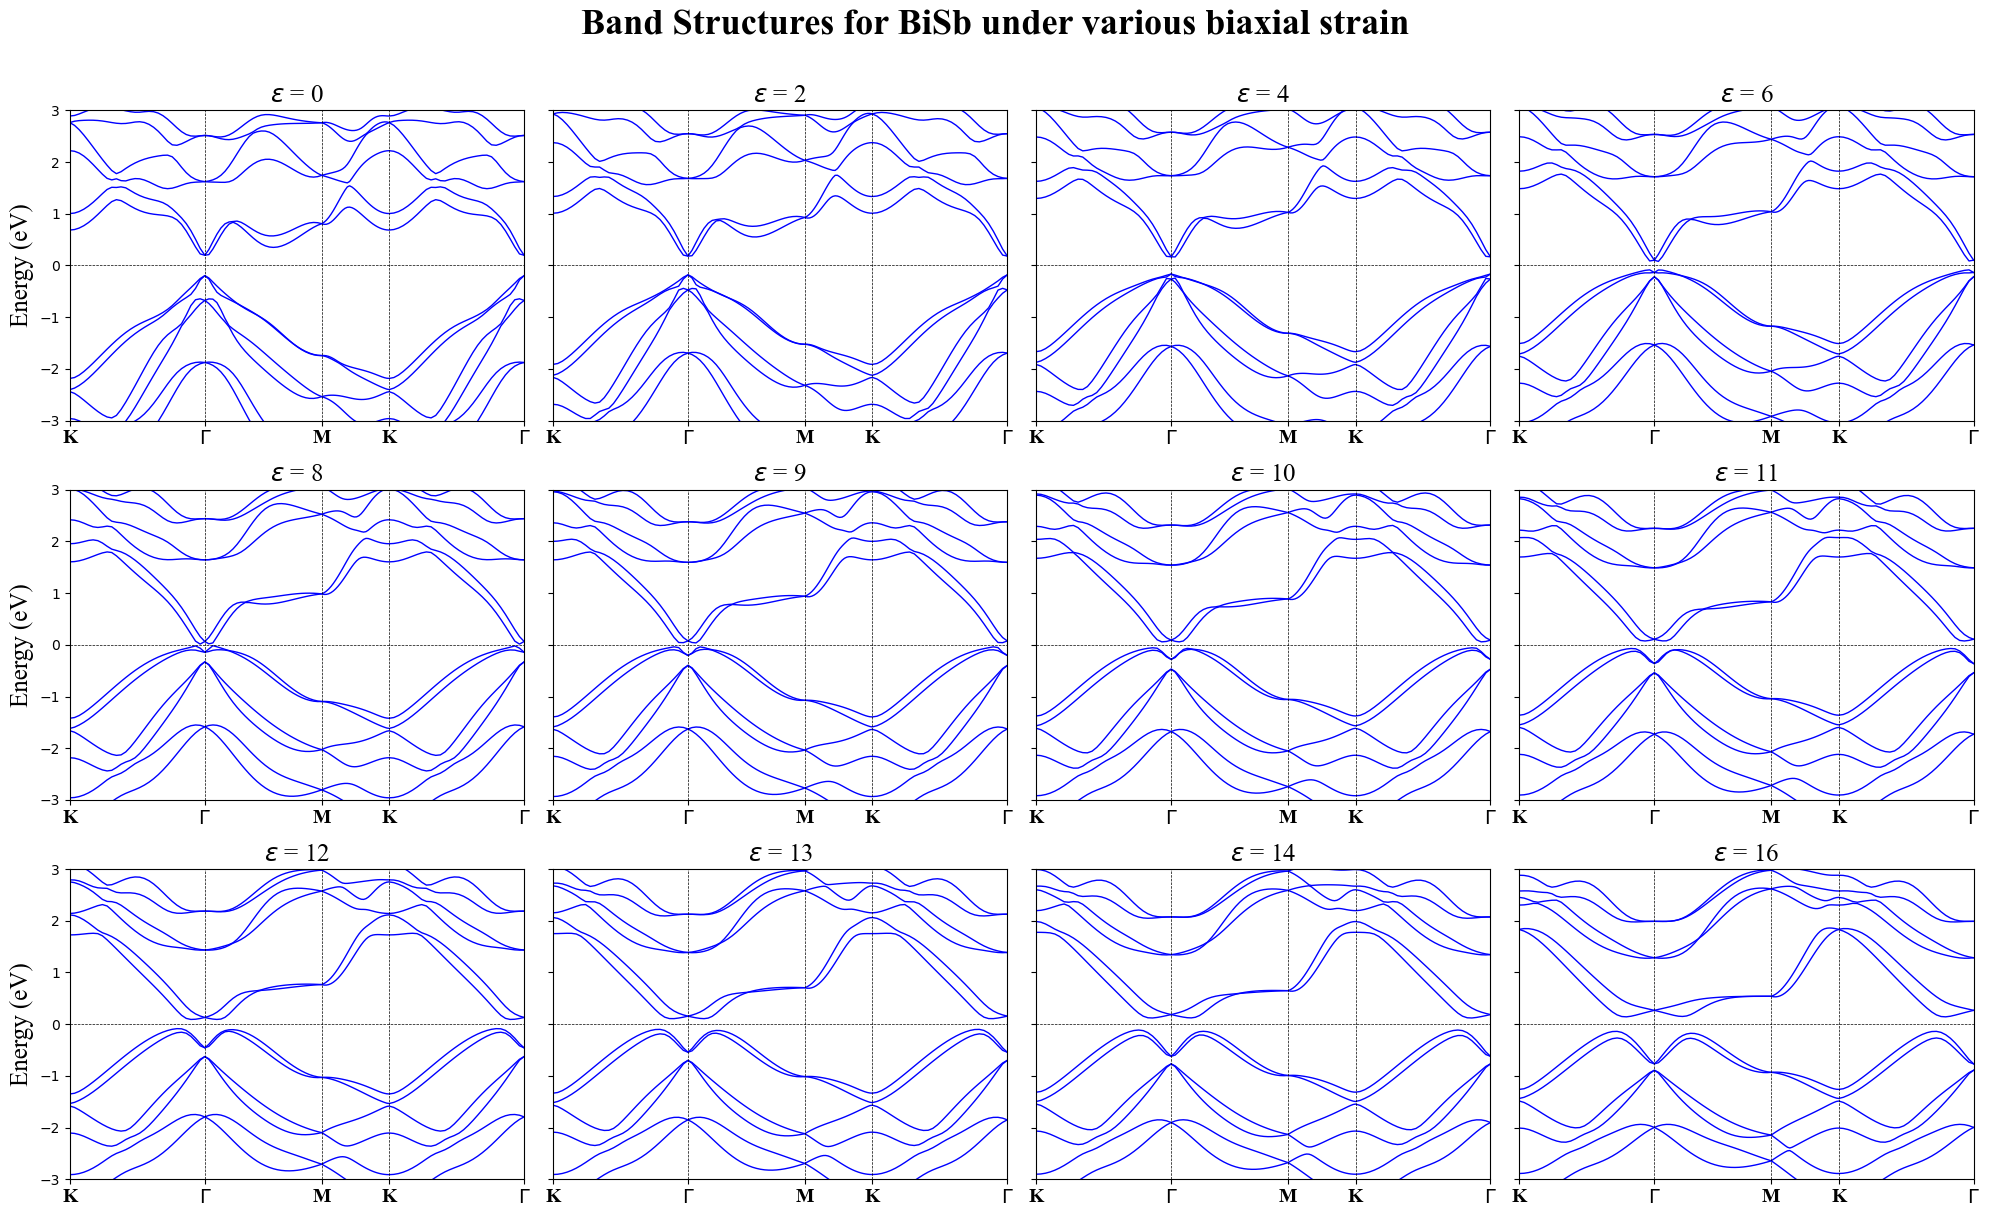

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [0, 2, 4, 6, 8, 9, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"e{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for BiSb under various biaxial strain', fontsize=26, fontname="Times New Roman",fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

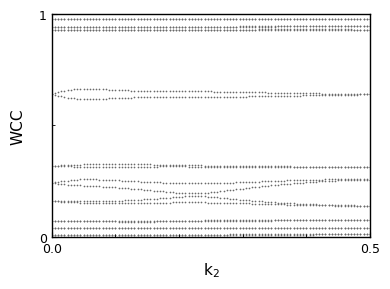

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = '#696969'

data = np.loadtxt("e0-wanniercenter3D_Z2_6.dat")

fig, ax = plt.subplots(figsize=(4, 3))

ax.scatter(data[:, 0] / 2, data[:, 1],
           s=1.5, color=LCOLOR, marker='o', linewidths=0)

ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1)

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.tick_params(axis='x', which='both', direction='in', labelsize=9)

ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

ax.set_xlabel(r'k$_2$', fontsize=11)
ax.set_ylabel('WCC', rotation=90, fontsize=11, labelpad=10)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

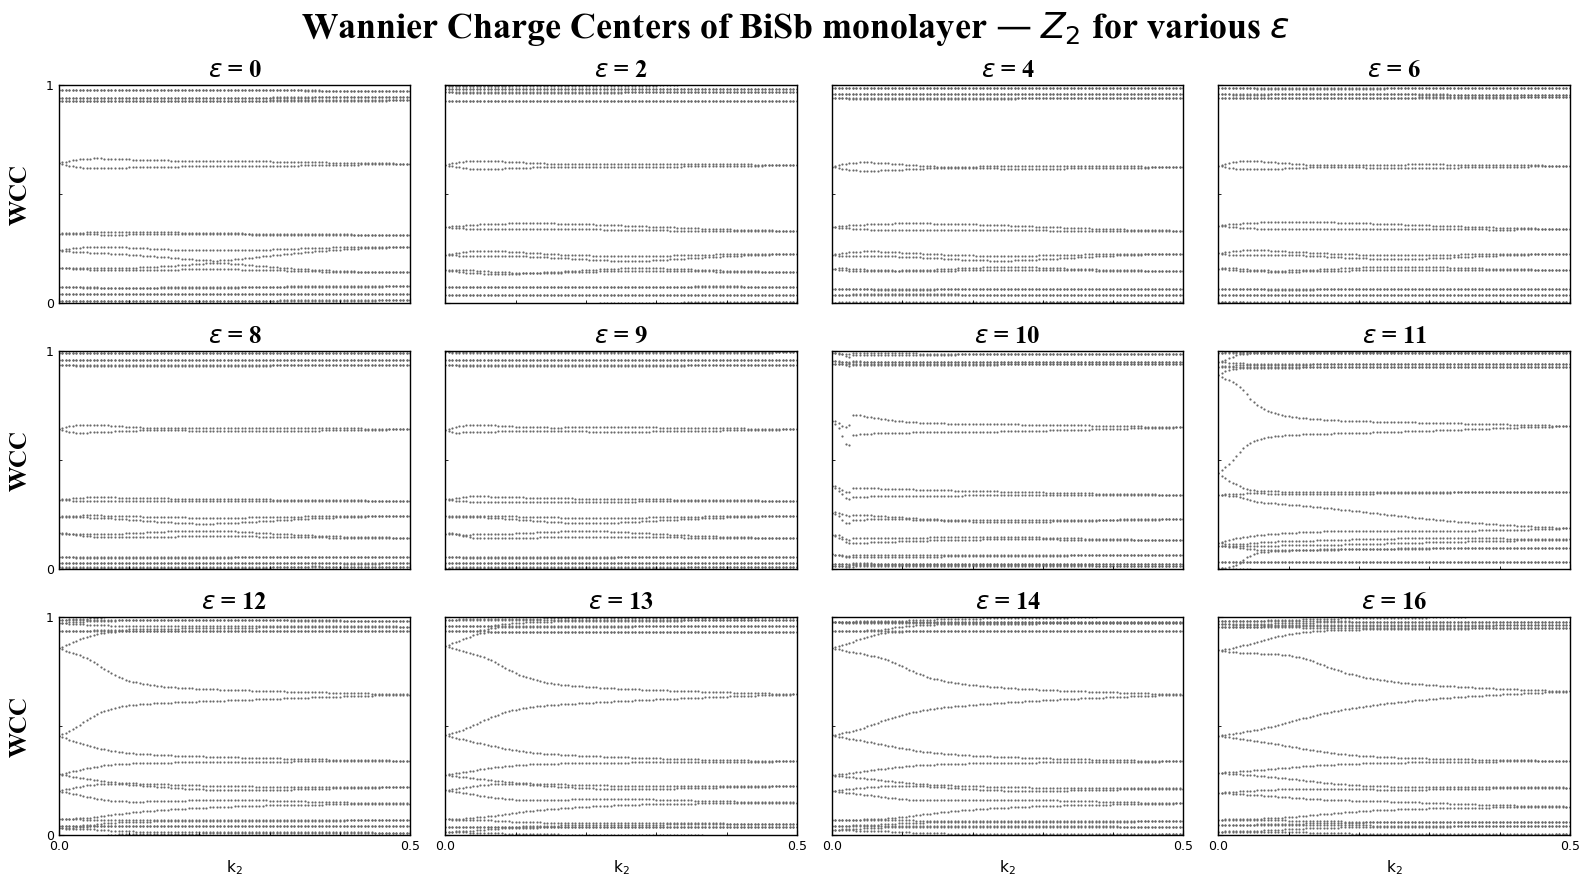

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = '#696969'
file_indices = [0, 2, 4, 6, 8, 9, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"e{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2.5, color=LCOLOR, marker='o', linewidths=0)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiSb monolayer — $Z_2$ for various $\epsilon$', fontname="Times New Roman",fontweight="bold",fontsize=26)
plt.tight_layout()
plt.savefig("wannier_centers_comparison.png", dpi=300)
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_22904\2711016197.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(dataset_file_bi, comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_22904\2711016197.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(dataset_file_sb, comment='#', delim_whitespace=True, header=None, skiprows=2)


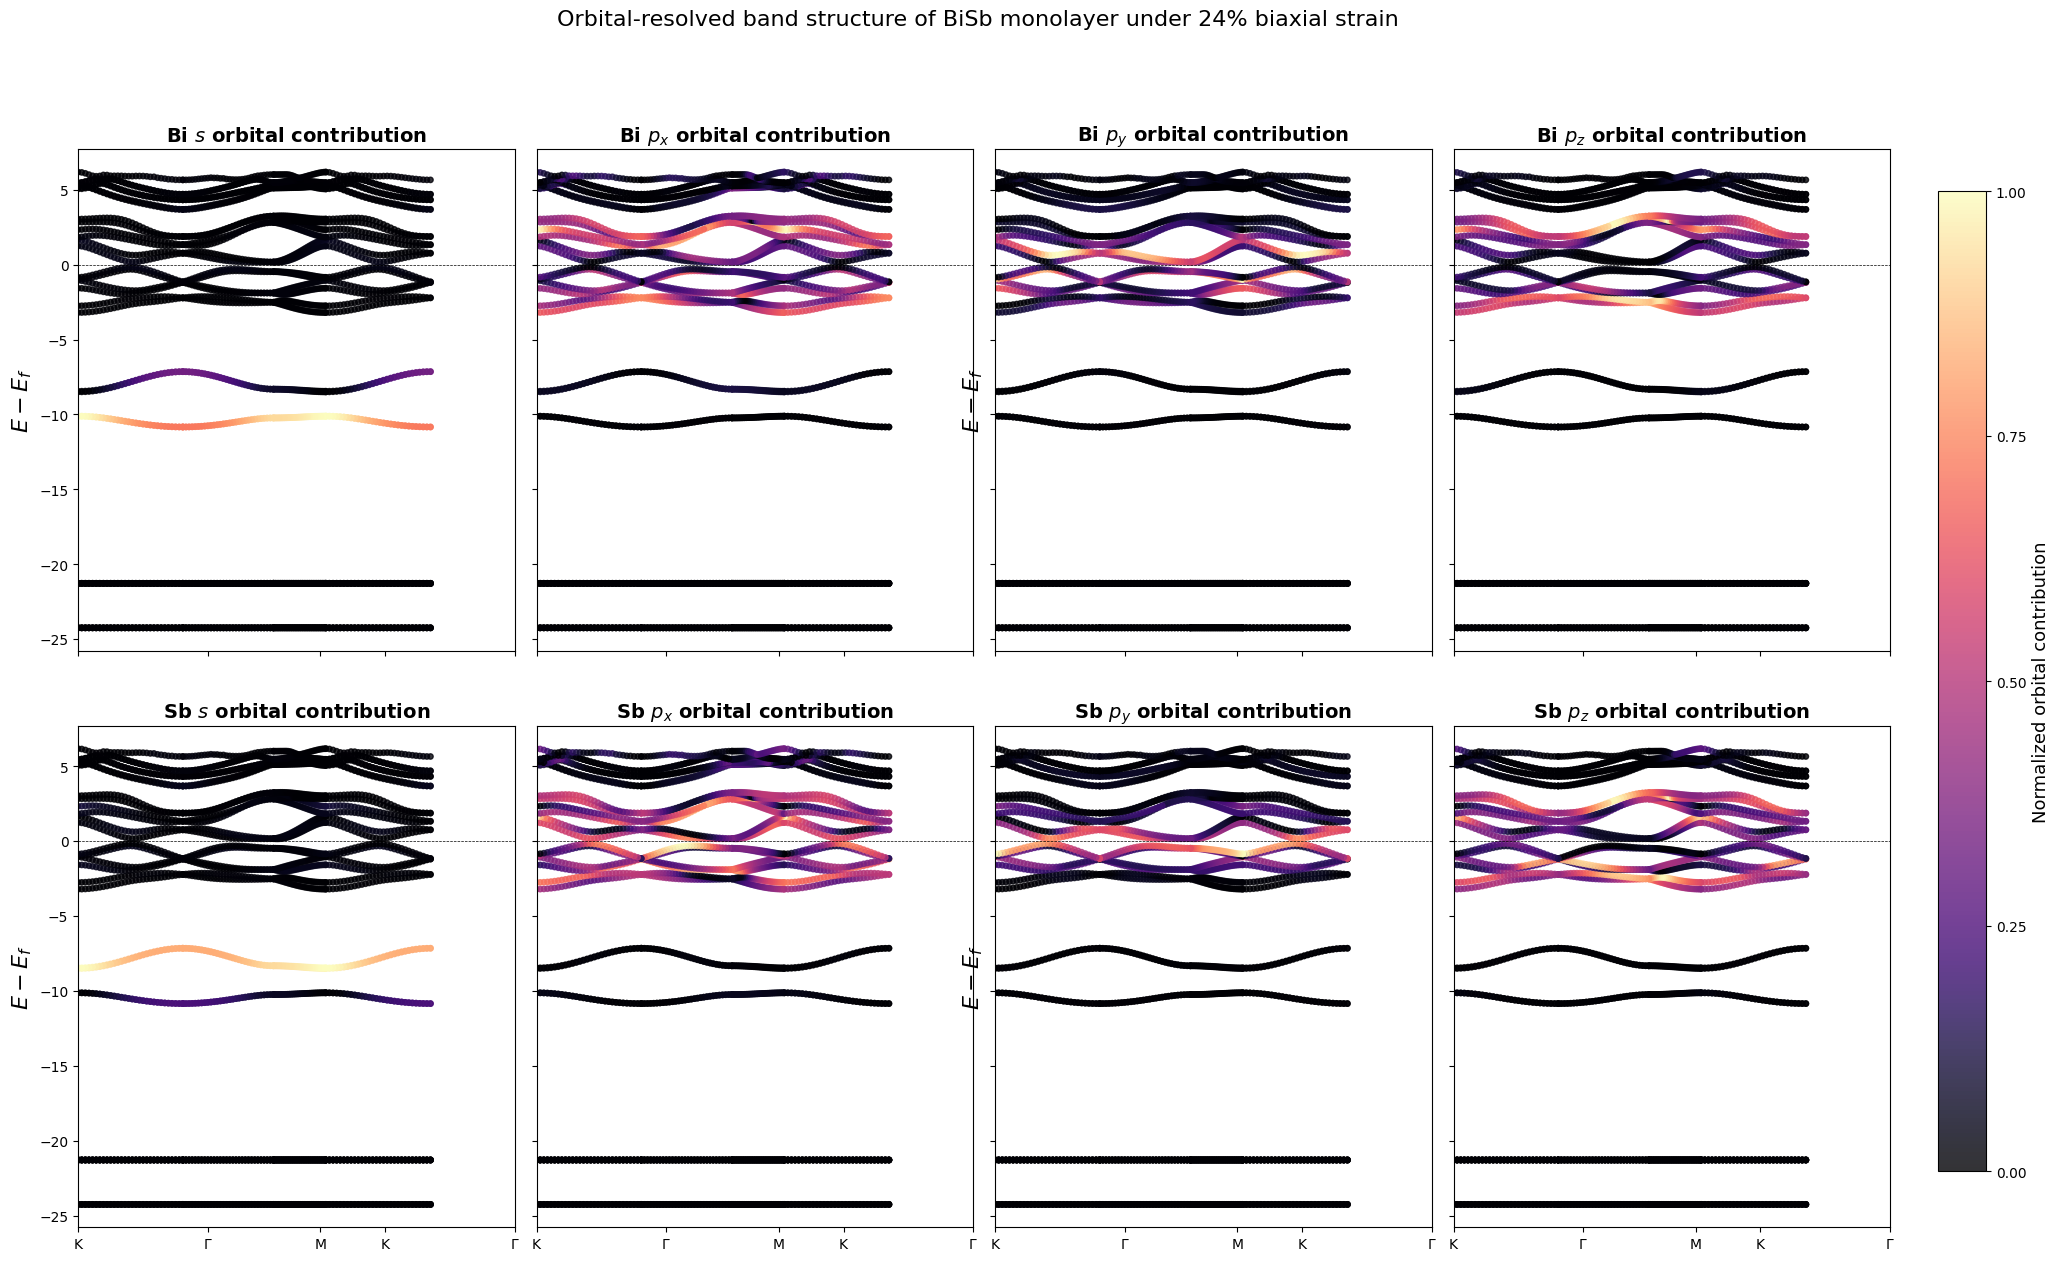

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_orbital_band_structure(strain):

    dataset_file_bi = f"e{strain}-PBAND_Bi_SOC.dat"
    dataset_file_sb = f"e{strain}-PBAND_Sb_SOC.dat"

    data_bi = pd.read_csv(dataset_file_bi, comment='#', delim_whitespace=True, header=None, skiprows=2)
    data_sb = pd.read_csv(dataset_file_sb, comment='#', delim_whitespace=True, header=None, skiprows=2)

    k = np.array(data_bi[0])
    e = np.array(data_bi[1])

    bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]
    sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

    def local_norm(arr):
        return (arr - arr.min()) / (arr.max() - arr.min())

    bi_norms = [local_norm(v) for v in bi_vals]
    sb_norms = [local_norm(v) for v in sb_vals]

    orbitals = [bi_norms[0], bi_norms[1], bi_norms[2], bi_norms[3],
                sb_norms[0], sb_norms[1], sb_norms[2], sb_norms[3]]

    names = ['Bi $s$', 'Bi $p_x$', 'Bi $p_y$', 'Bi $p_z$',
             'Sb $s$',  'Sb $p_x$', 'Sb $p_y$', 'Sb $p_z$']

    cmap = 'magma'

    high_symmetry_points = [0, 0.982, 1.833, 2.324, 3.306]
    high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

    fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
    fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
    axes = axes.flatten()

    last_scatter = None

    for idx, (orbital, name) in enumerate(zip(orbitals, names)):
        ax = axes[idx]

        scatter = ax.scatter(
            k, e,
            c=orbital,
            s=15, cmap=cmap, alpha=0.8,
            vmin=0, vmax=1
        )
        last_scatter = scatter

        ax.set_title(f'{name} orbital contribution', fontsize=14, fontweight='bold')
        #ax.set_ylim(-5, 5)
        ax.set_xlim(min(k), max(k))

        ax.axhline(0, ls='--', lw=0.5, color='black')
        ax.set_xticks(high_symmetry_points)
        ax.set_xticklabels(high_symmetry_labels)

        if idx % 2 == 0:
            ax.set_ylabel(r'$E-E_f$', fontsize=16)

    # --- Single global colorbar on the right ---
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(last_scatter, cax=cbar_ax)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
    cbar.set_label('Normalized orbital contribution', fontsize=13)
    cbar.ax.tick_params(labelsize=10)

    plt.suptitle(
        f'Orbital-resolved band structure of BiSb monolayer under {strain}% biaxial strain',
        fontsize=16, y=0.98
    )
    plt.show()


# --- Example usage ---
strain_values = [0, 2, 4, 6, 8, 9, 10, 11, 12, 13, 14, 16,24]

plot_orbital_band_structure(strain_values[-1])  # Single strain
# for strain in strain_values:               # All strains (uncomment to loop)
#     plot_orbital_band_structure(strain)

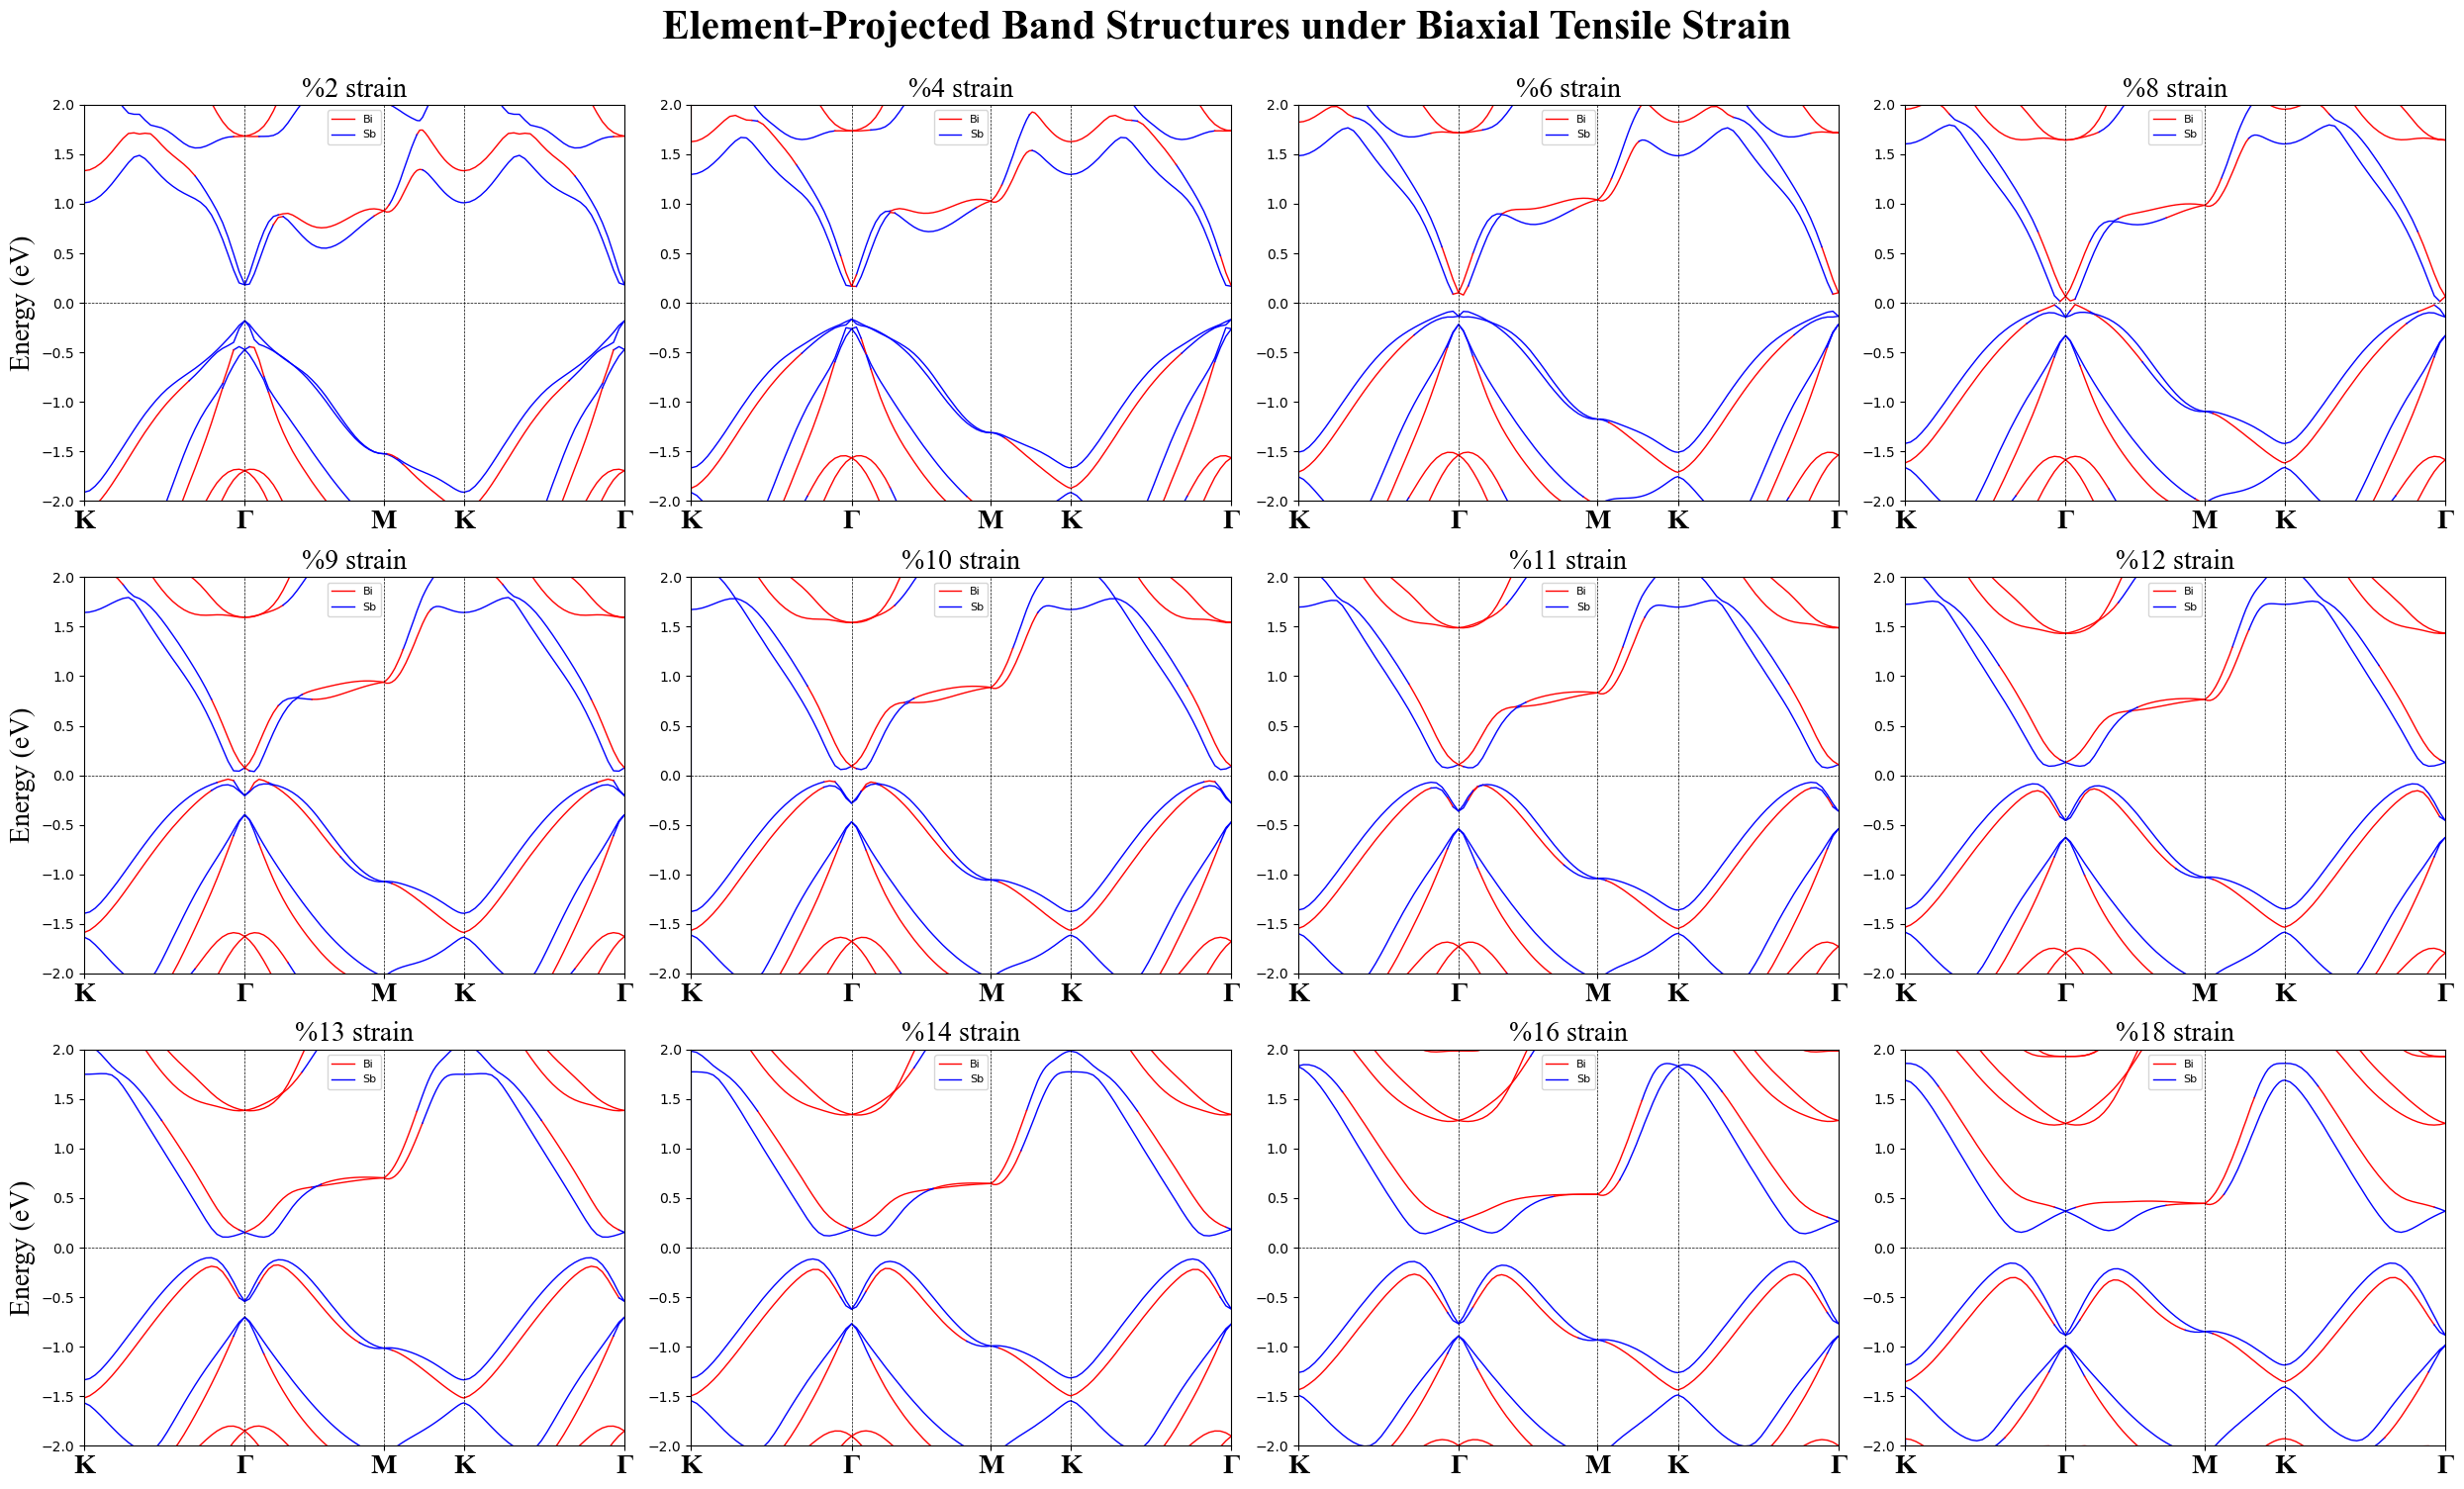

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_9 = np.loadtxt("9-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_11 = np.loadtxt("11-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_13 = np.loadtxt("13-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")
data_16 = np.loadtxt("16-PBAND_ELEMENTS_SOC.dat")
data_18 = np.loadtxt("18-PBAND_ELEMENTS_SOC.dat")
data_20 = np.loadtxt("20-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14, data_16, data_18, data_20]

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

# Collect all datasets and their corresponding KLABELS files
labels = ['2', '4', '6', '8', '9' ,'10', '11' ,'12', '13' ,'14', '16', '18']

datasets = []
klabels_list = []
for label in labels:
    datasets.append(np.loadtxt(f"{label}-PBAND_ELEMENTS_SOC.dat"))
    klabels_list.append(read_klabels(f"labels/{label}-KLABELS"))

# Define elements and their corresponding columns
element_names = ['Bi', 'Sb']
element_columns = [2, 3]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

high_sym_labels = ['K', 'Γ', 'M', 'K' ,'Γ']

# Create figure with subplots
fig, axes = plt.subplots(3, 4, figsize=(25, 15))
axes = axes.flatten()

for idx, (elemented_data, label, sym_points) in enumerate(zip(datasets, labels, klabels_list)):
    ax = axes[idx]

    # Find dominant element at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)

    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))

    labeled_elements = set()

    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]

        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]

        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, label=elem_label, linewidth=1)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, linewidth=1)

    for point in sym_points:
        ax.axvline(point,lw=0.5,color='black',ls='--')

    ax.axhline(0,lw=0.5,color='black',ls='--')

    ax.set_xticks(sym_points)
    ax.set_xticklabels(high_sym_labels,fontname="Times New Roman",fontweight="bold",fontsize=20)
    ax.set_xlim(min(elemented_data[:, 0]), max(elemented_data[:, 0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain',fontsize=20,fontname="Times New Roman")
    if idx == 0 or idx == 4 or idx ==8:
        ax.set_ylabel('Energy (eV)',fontsize=20,fontname="Times New Roman")
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Biaxial Tensile Strain ",
            fontsize=30,fontname="Times New Roman", fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()